In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

%config InlineBackend.figure_format = 'retina'

In [2]:
blobs = pd.read_csv('/Users/konansul/Desktop/course-ml/DATA/cluster_blobs.csv')

In [3]:
blobs

,X1,X2
0,4.645333,6.822294
1,4.784032,6.422883
2,-5.851786,5.774331
3,-7.459592,6.456415
4,4.918911,6.961479
...,...,...
1495,0.882673,-6.786272
1496,0.946854,-7.254512
1497,3.180138,6.608660
1498,5.454552,6.461246


<Axes: xlabel='X1', ylabel='X2'>

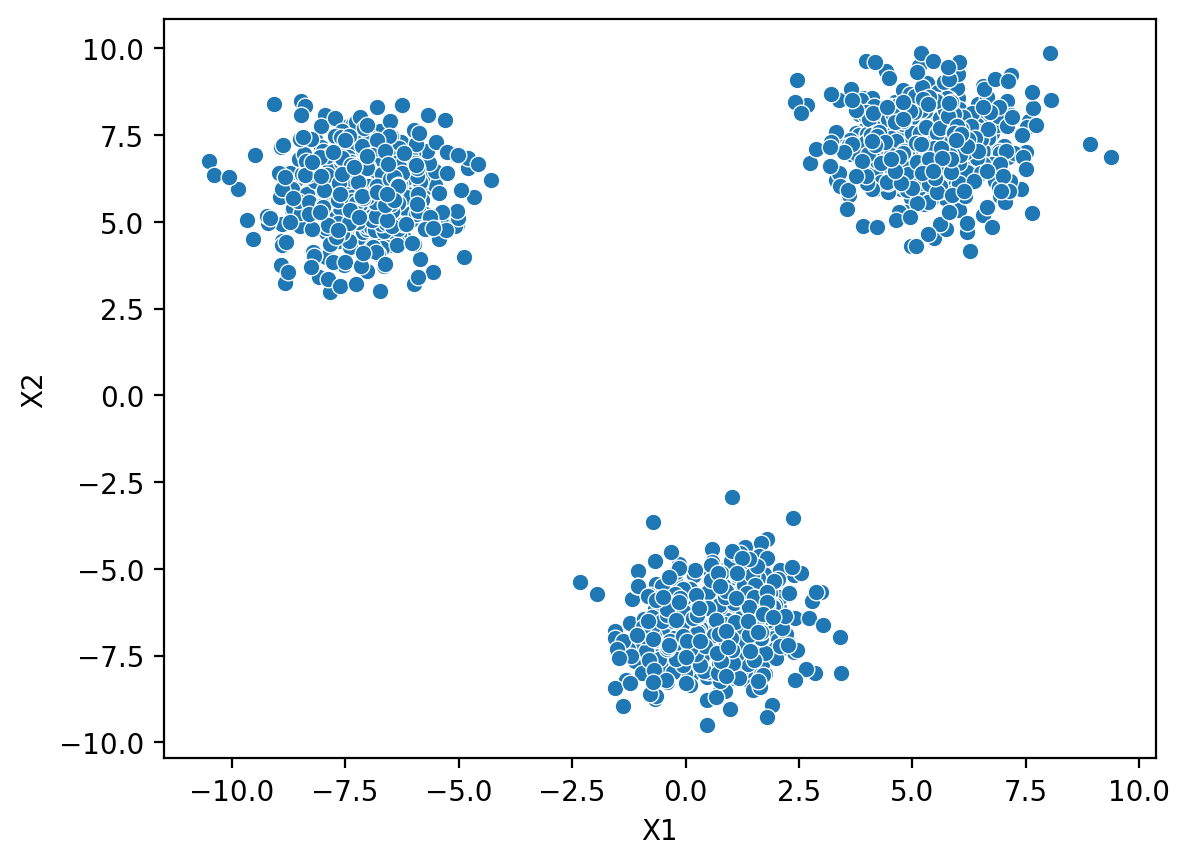

In [4]:
sns.scatterplot(x = 'X1', y = 'X2', data = blobs)

In [5]:
moons = pd.read_csv('/Users/konansul/Desktop/course-ml/DATA/cluster_moons.csv')

In [6]:
moons

,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164
...,...,...
1495,1.957344,0.187184
1496,0.962394,0.384304
1497,-0.761893,0.581666
1498,1.803858,-0.154705


<Axes: xlabel='X1', ylabel='X2'>

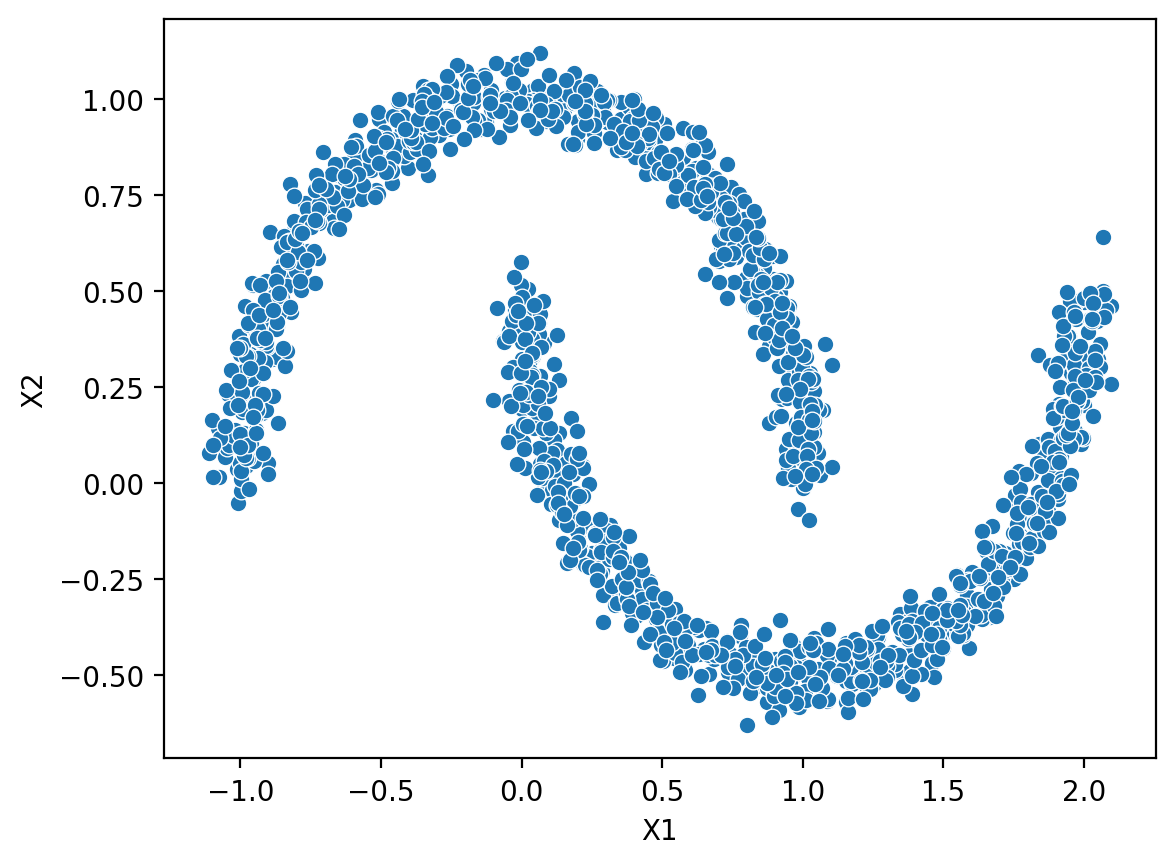

In [7]:
sns.scatterplot(x = 'X1', y = 'X2', data = moons)

In [8]:
circles = pd.read_csv('/Users/konansul/Desktop/course-ml/DATA/cluster_circles.csv')

In [9]:
circles

,X1,X2
0,-0.348677,0.010157
1,-0.176587,-0.954283
2,0.301703,-0.113045
3,-0.782889,-0.719468
4,-0.733280,-0.757354
...,...,...
1495,-0.297506,0.077834
1496,0.082555,-0.270371
1497,0.279533,-0.109435
1498,0.027432,-0.264891


<Axes: xlabel='X1', ylabel='X2'>

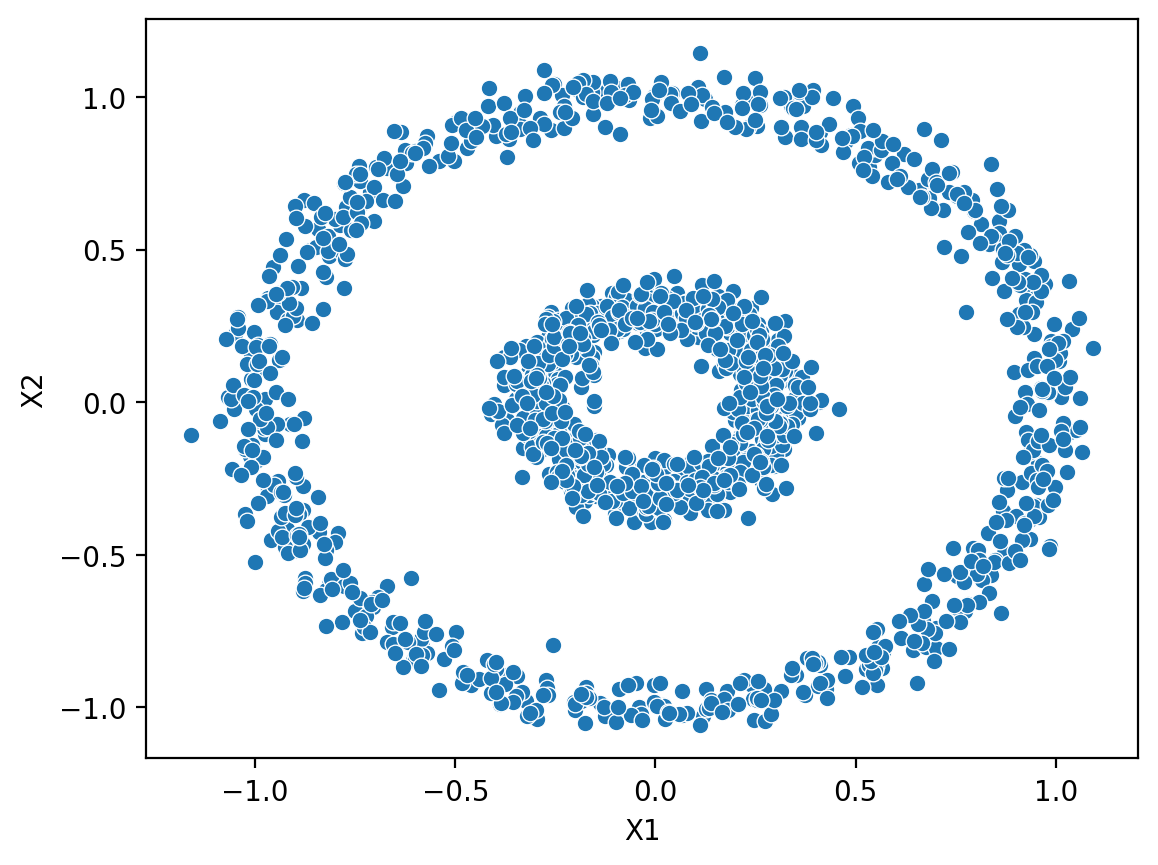

In [10]:
sns.scatterplot(x = 'X1', y = 'X2', data = circles)

In [11]:
def plot(model, X):
    labels = model.fit_predict(X)
    plt.figure(figsize = (7, 5))
    sns.scatterplot(x = 'X1', y = 'X2', hue = labels, data = X, palette =  'Set1')

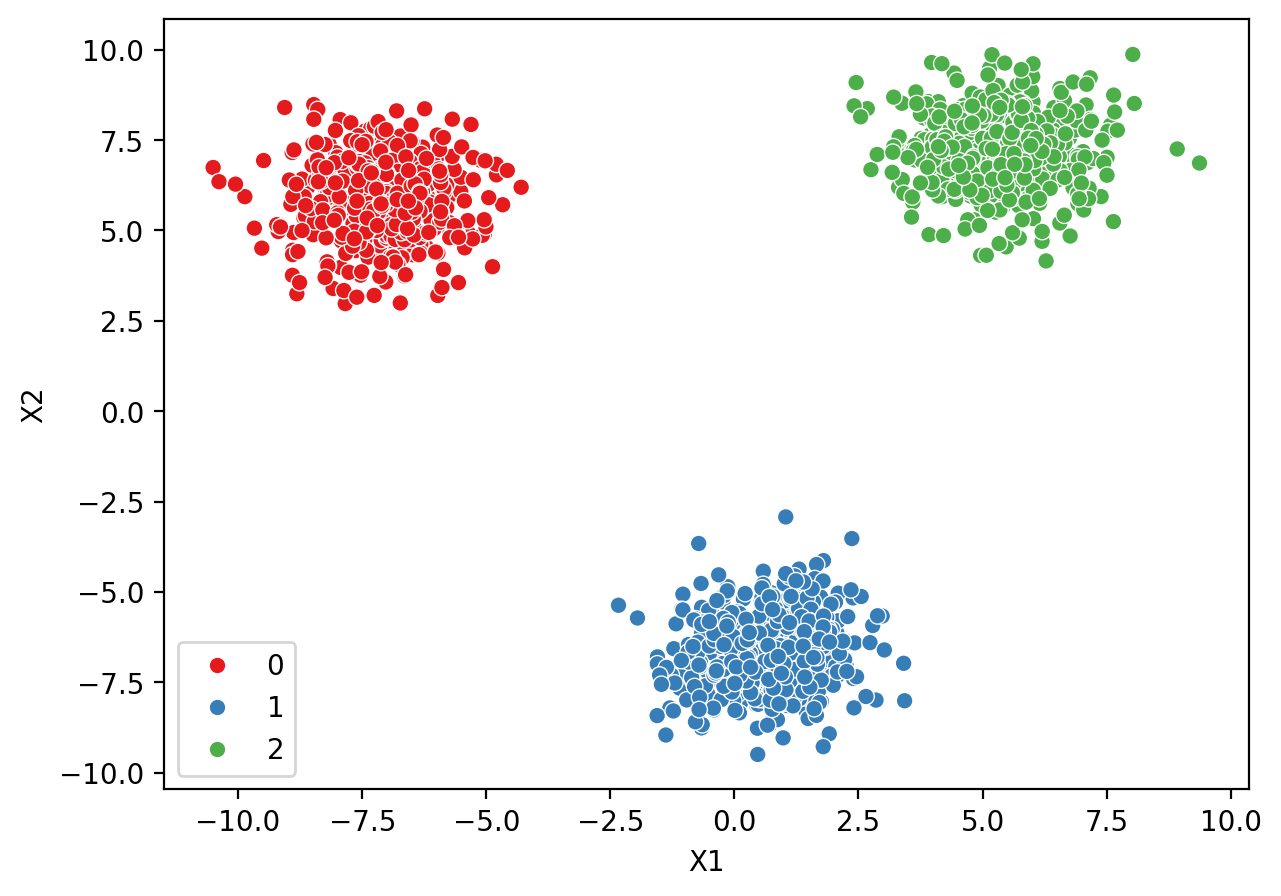

In [12]:
plot(KMeans(n_clusters = 3), blobs)

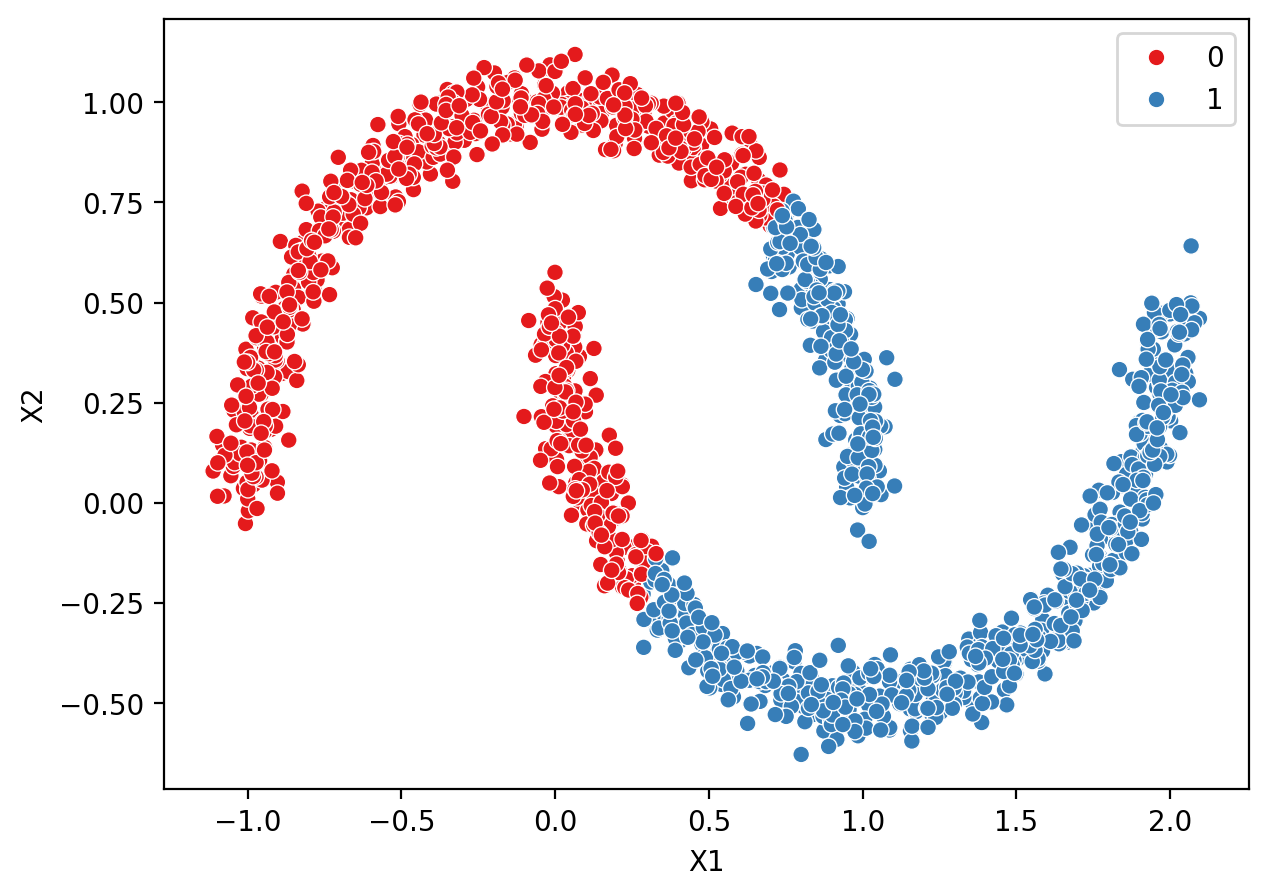

In [13]:
plot(KMeans(n_clusters = 2), moons)

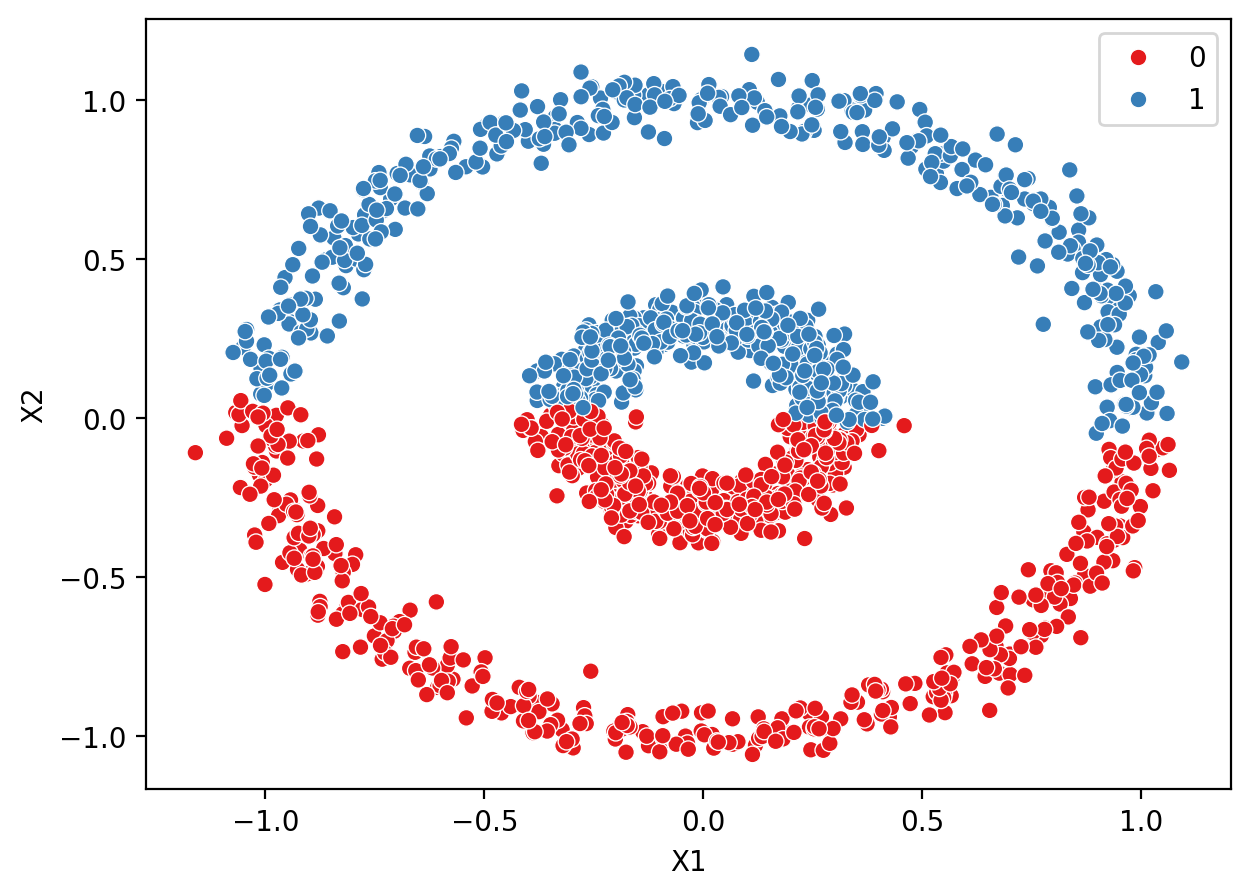

In [14]:
plot(KMeans(n_clusters = 2), circles) 

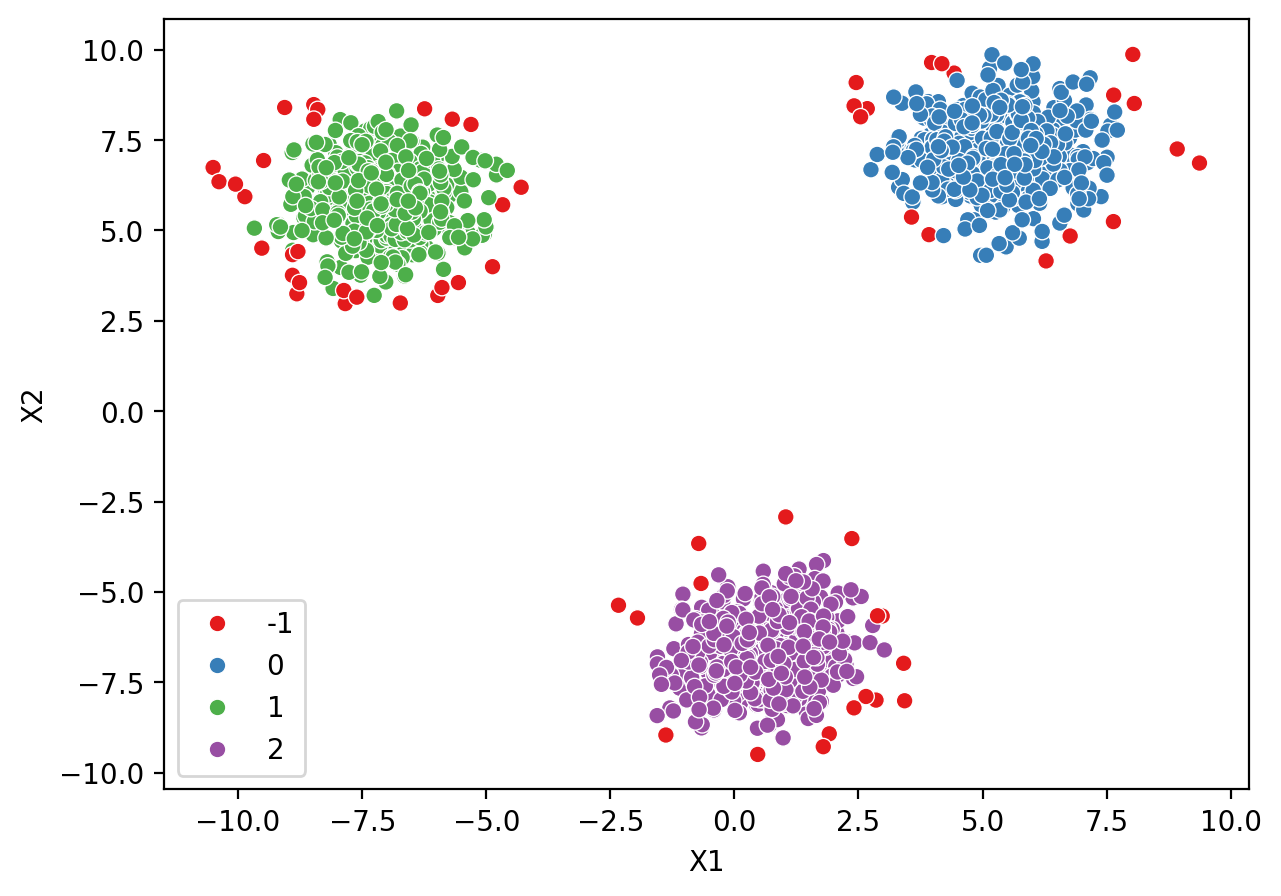

In [15]:
plot(DBSCAN(), blobs)

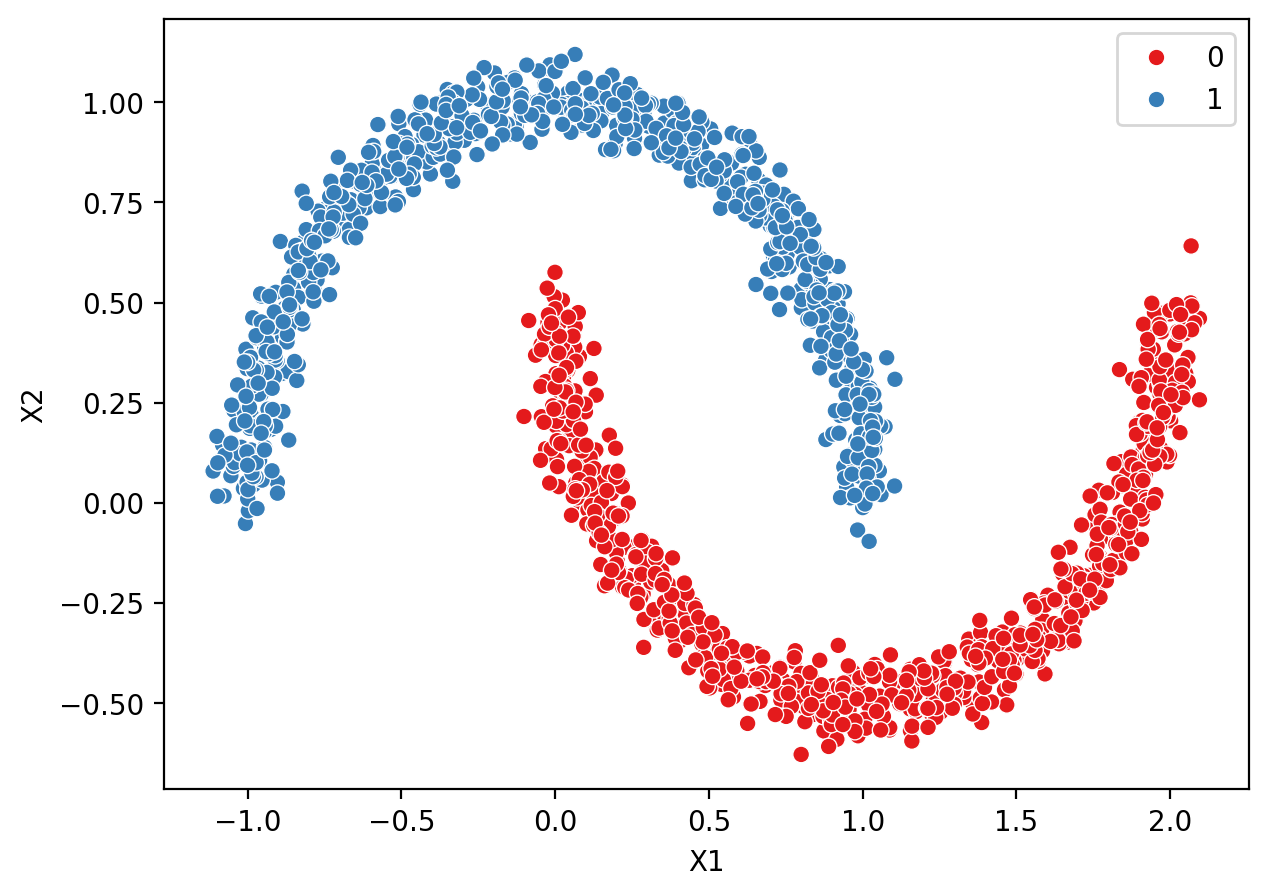

In [16]:
plot(DBSCAN(eps = 0.15), moons)

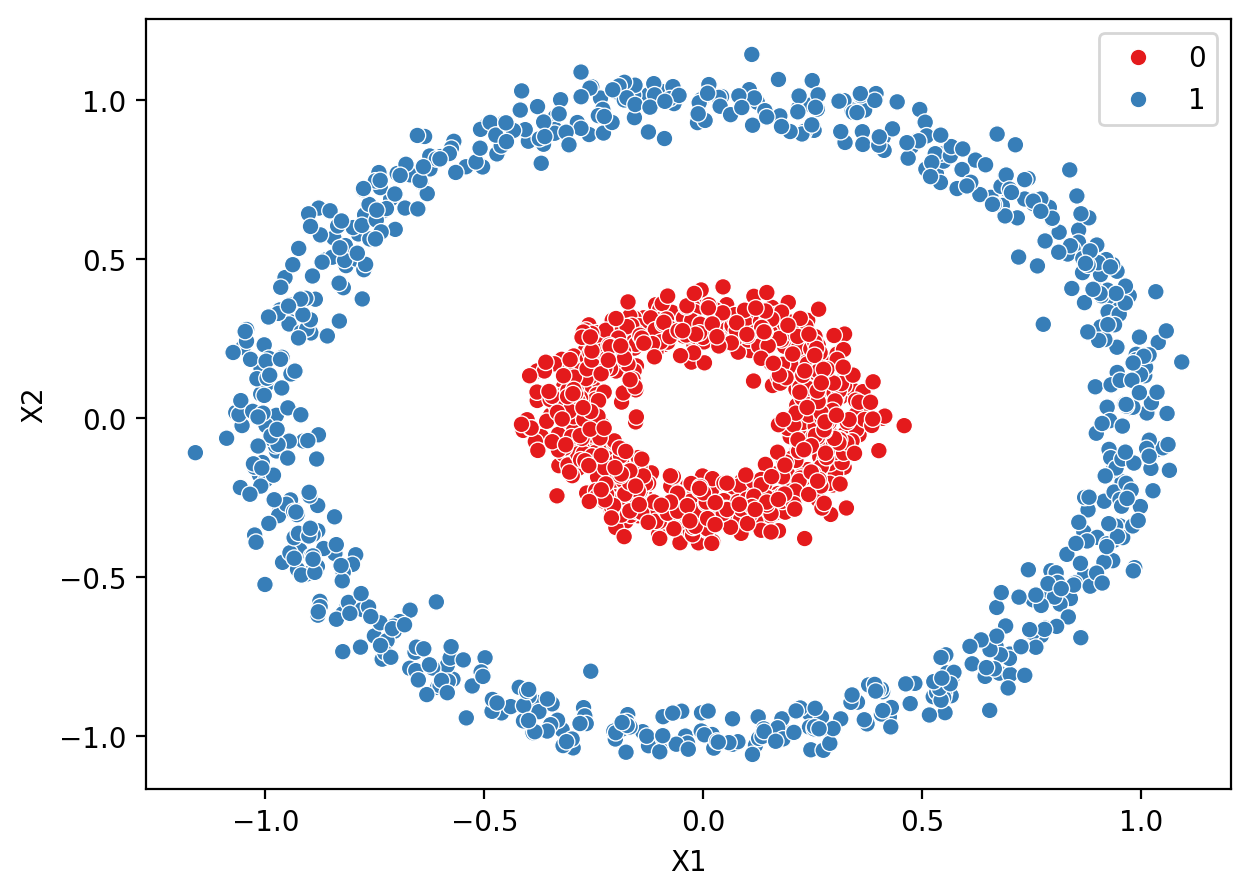

In [17]:
plot(DBSCAN(eps = 0.15), circles)

In [18]:
two_blobs = pd.read_csv('/Users/konansul/Desktop/course-ml/DATA/cluster_two_blobs.csv')

In [19]:
two_blobs_outliers = pd.read_csv('/Users/konansul/Desktop/course-ml/DATA/cluster_two_blobs_outliers.csv')

<Axes: xlabel='X1', ylabel='X2'>

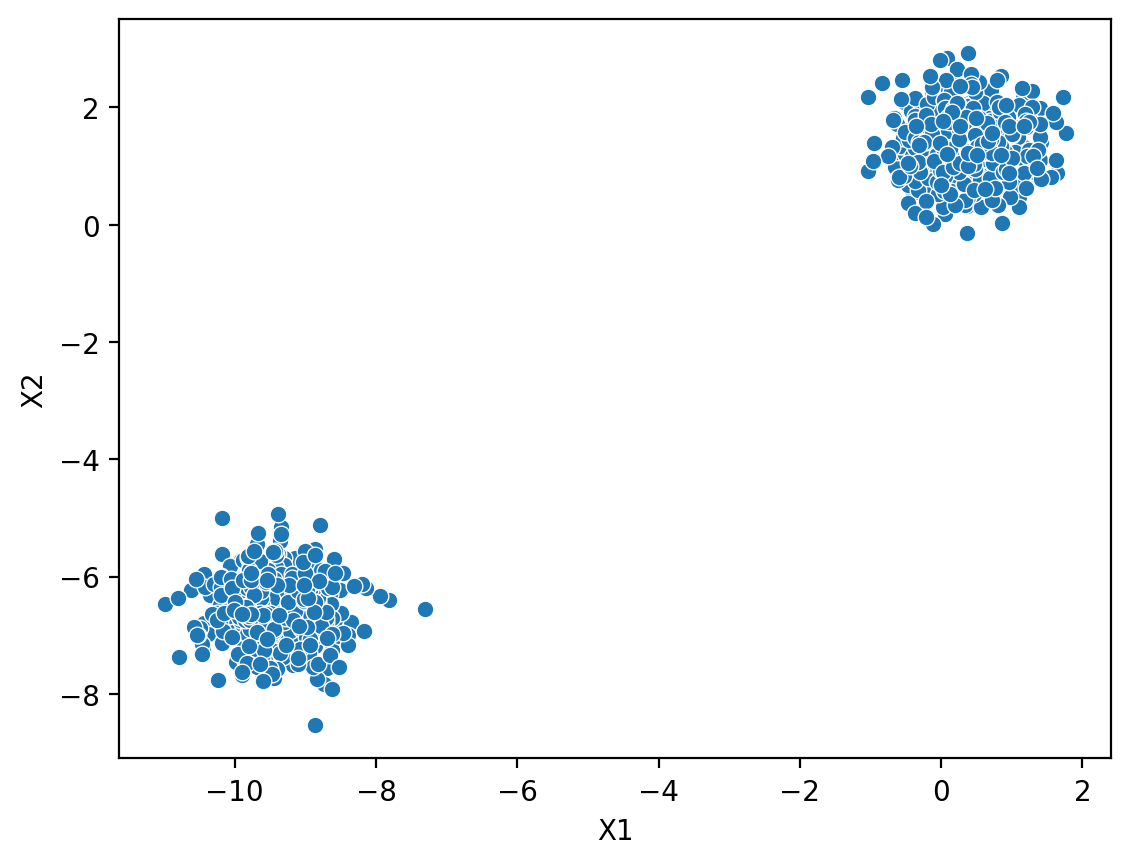

In [20]:
sns.scatterplot(x = 'X1', y = 'X2', data = two_blobs)

<Axes: xlabel='X1', ylabel='X2'>

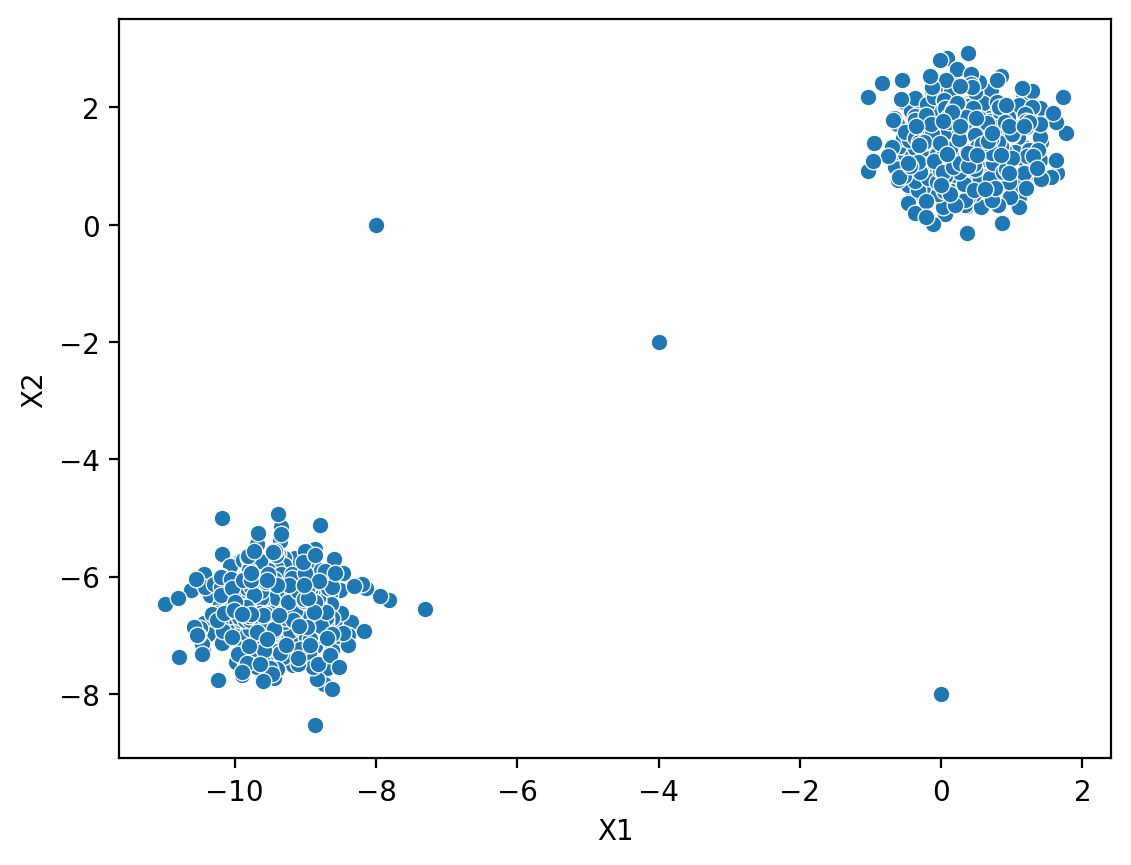

In [21]:
sns.scatterplot(x = 'X1', y = 'X2', data = two_blobs_outliers)

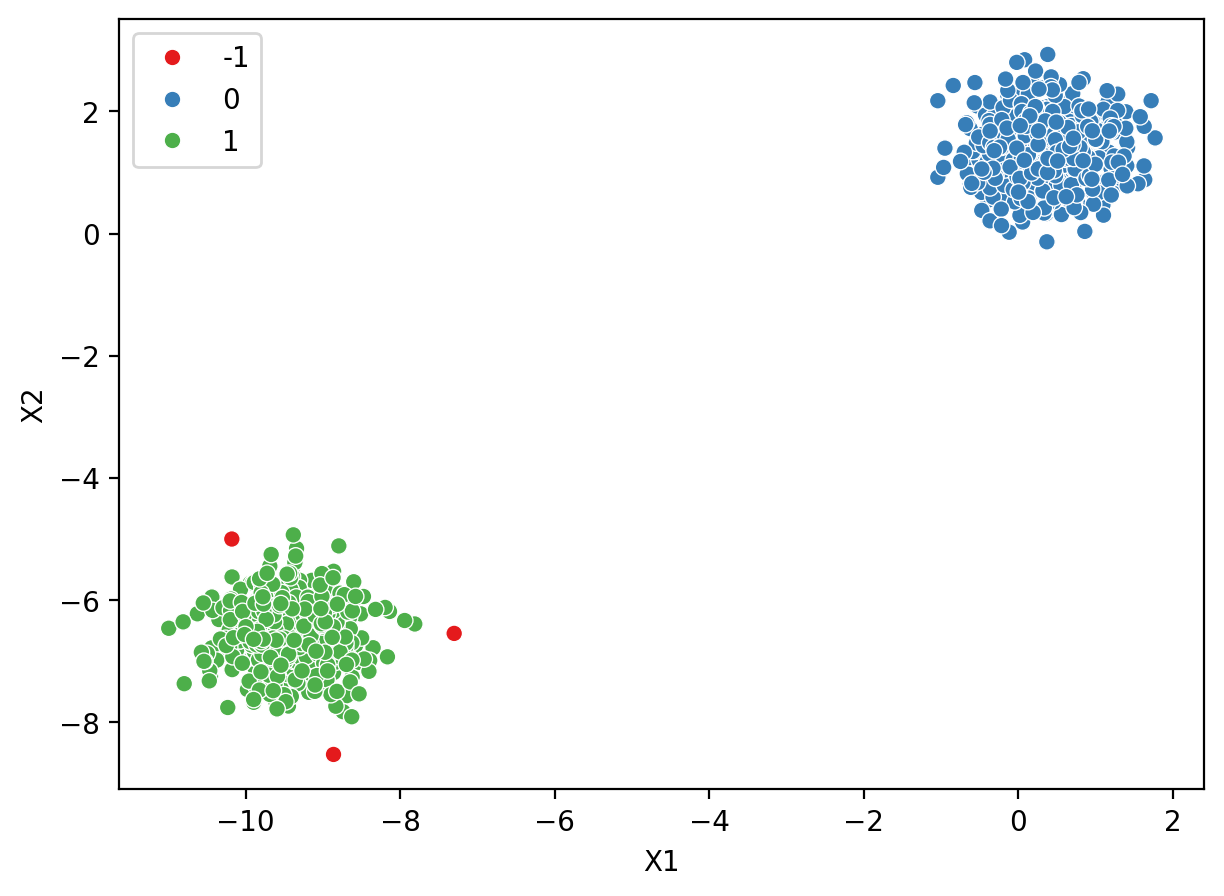

In [22]:
plot(DBSCAN(), two_blobs)

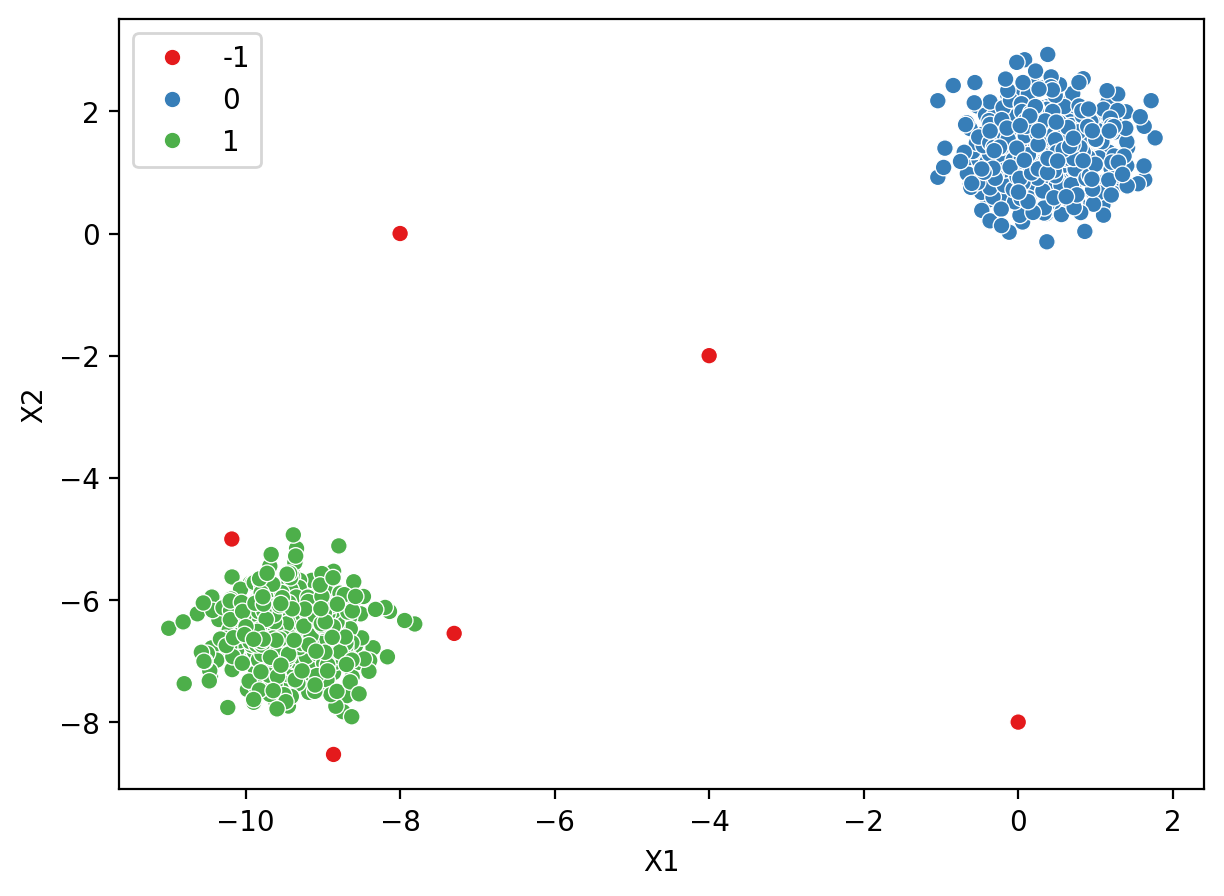

In [23]:
plot(DBSCAN(), two_blobs_outliers)

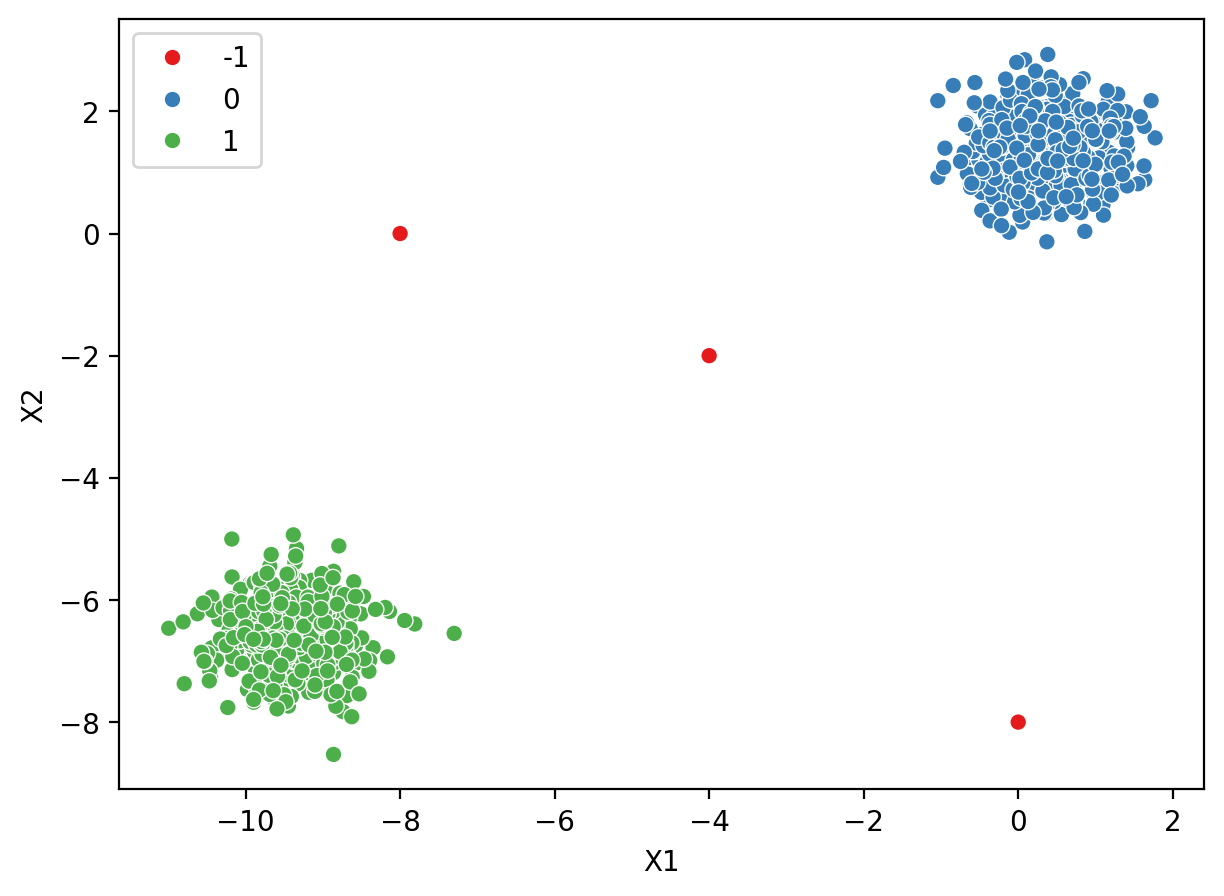

In [24]:
plot(DBSCAN(eps = 1), two_blobs_outliers)

In [25]:
dbscan = DBSCAN(eps = 1)

In [26]:
dbscan.fit_predict(two_blobs_outliers)[:10]

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 0])

In [27]:
labels = dbscan.labels_

In [28]:
np.sum(dbscan.labels_ == -1)

np.int64(3)

In [29]:
100 * np.sum(dbscan.labels_ == -1) / len(two_blobs_outliers)

np.float64(0.29910269192422734)

In [30]:
outlier_percent = [ ]

In [31]:
number_of_outliers = [ ]

In [32]:
for i in np.linspace(0.001, 7, 200):
    model = DBSCAN(eps = i)
    model.fit(two_blobs_outliers)

    number_of_outliers.append(np.sum(model.labels_ == -1))

    outlier_percent.append(100 * np.sum(model.labels_ == -1) / len(two_blobs_outliers))

(0.0, 10.0)

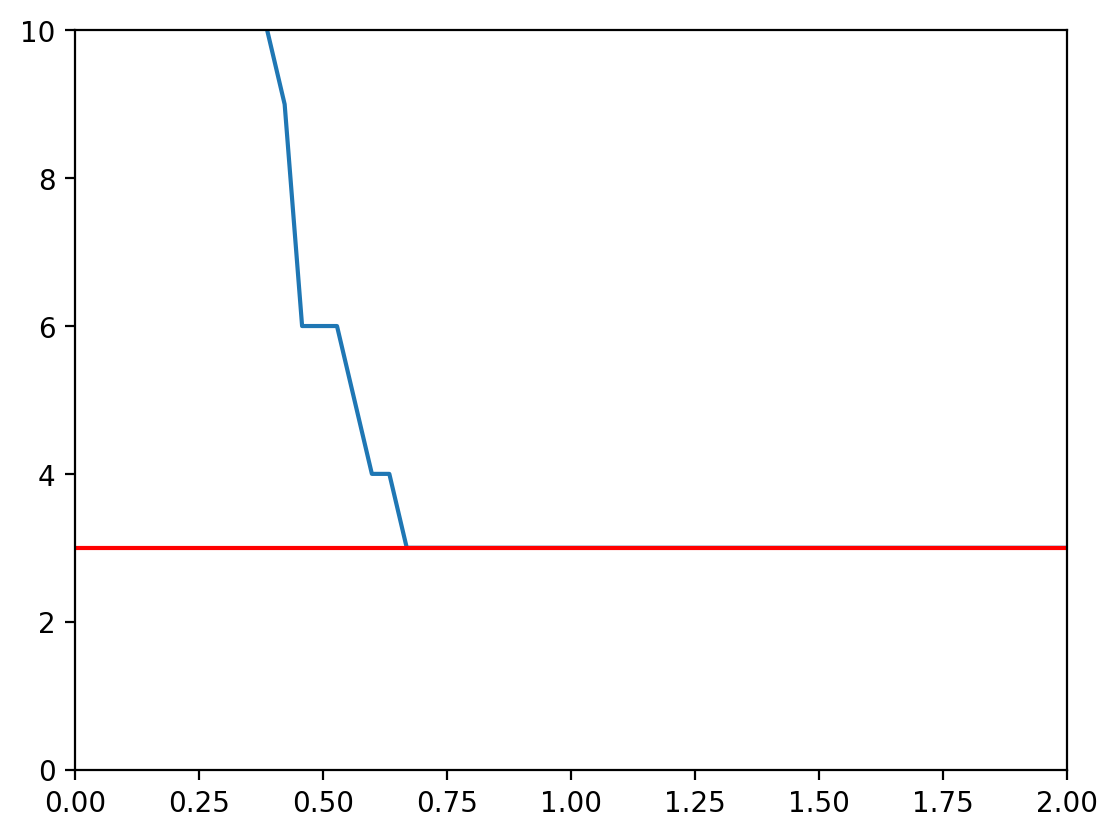

In [33]:
sns.lineplot(x = np.linspace(0.001, 7, 200), y = number_of_outliers)
plt.hlines(y = 3, xmin = 0, xmax = 2, color = 'red')
plt.xlim(0, 2)
plt.ylim(0, 10)

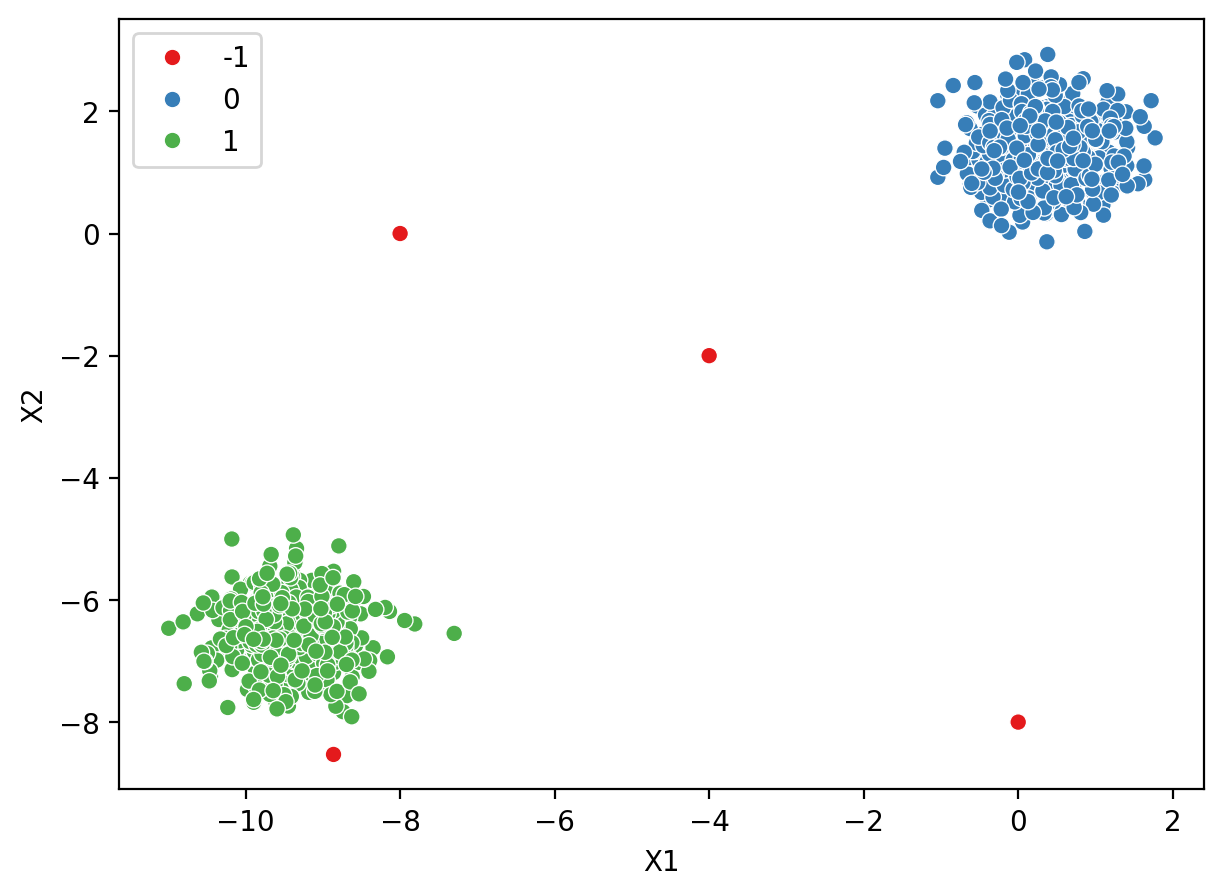

In [34]:
plot(DBSCAN(eps = 0.6), two_blobs_outliers)

(0.0, 10.0)

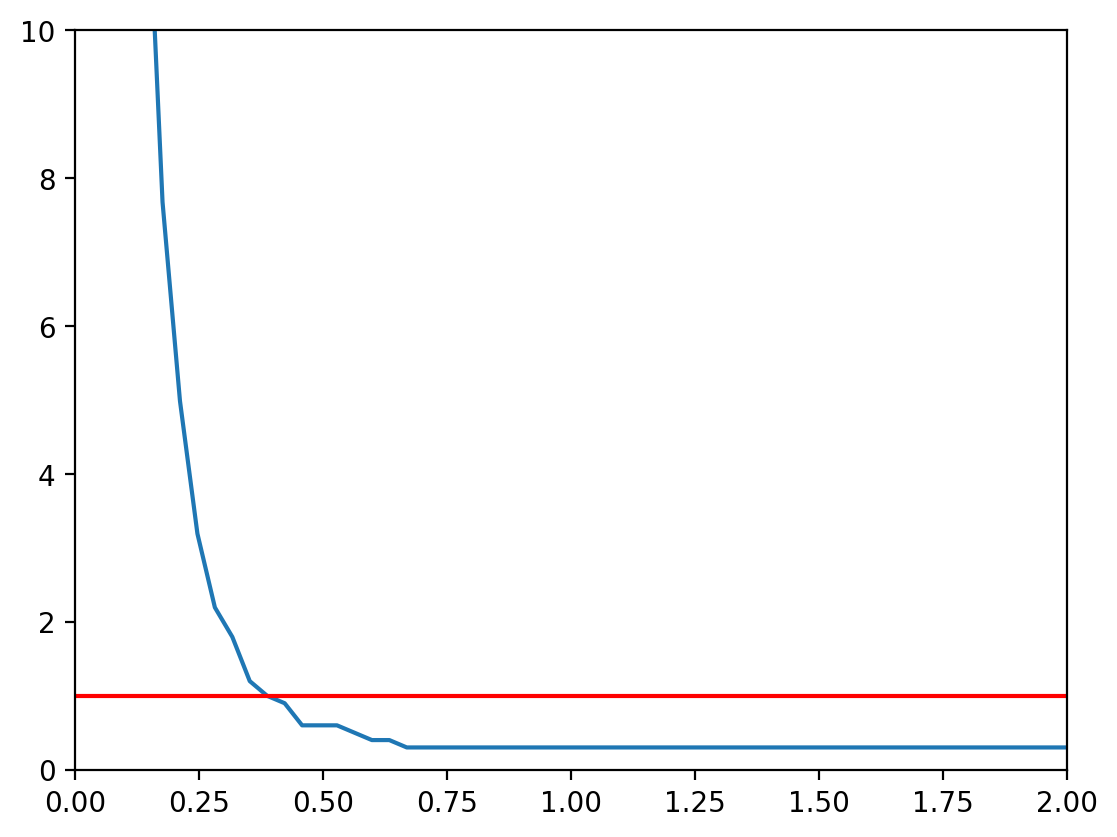

In [35]:
sns.lineplot(x = np.linspace(0.001, 7, 200), y = outlier_percent)
plt.hlines(y = 1, xmin = 0, xmax = 2, color = 'red')
plt.xlim(0, 2)
plt.ylim(0, 10)

In [36]:
outlier_percent = [ ]
number_of_outliers = [ ]

for n in np.arange(1, 100):
    model2 = DBSCAN(min_samples = n)
    model2.fit(two_blobs_outliers)

    number_of_outliers.append(np.sum(model2.labels_ == -1))

    outlier_percent.append(100 * np.sum(model2.labels_ == -1) / len(two_blobs_outliers))

(0.0, 10.0)

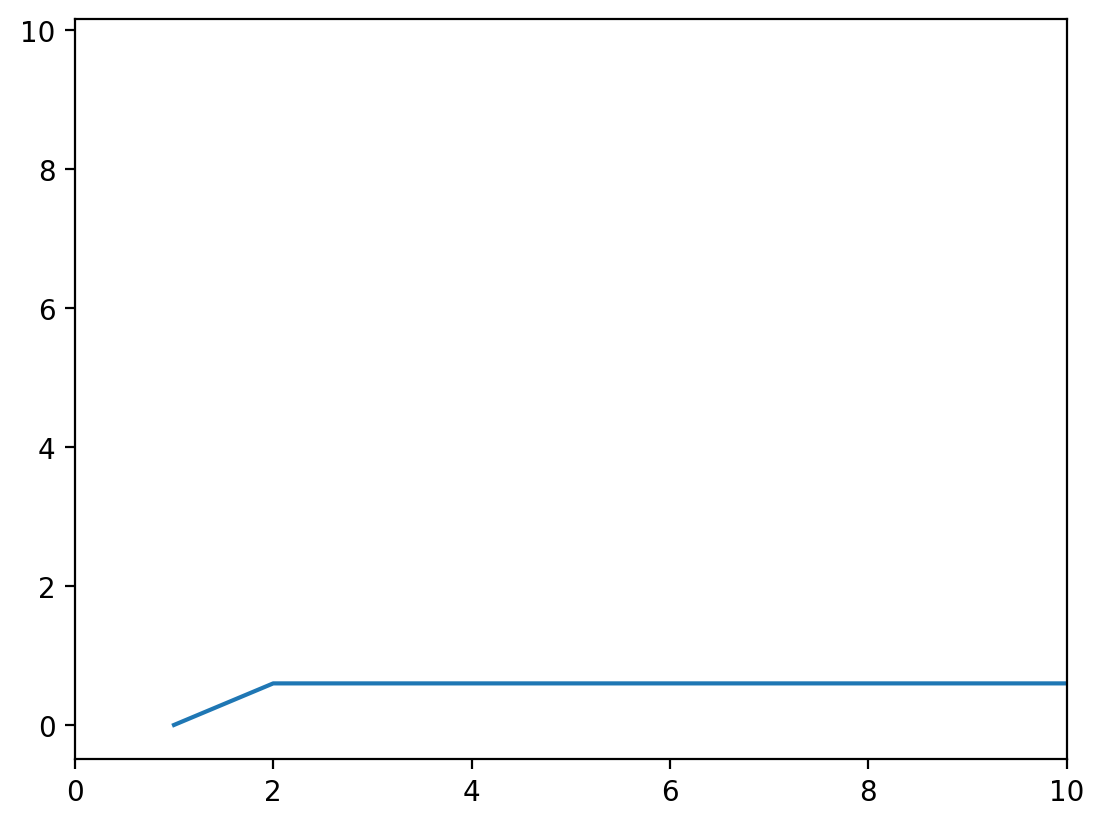

In [37]:
sns.lineplot(x = np.arange(1, 100), y = outlier_percent)
plt.xlim(0, 10)

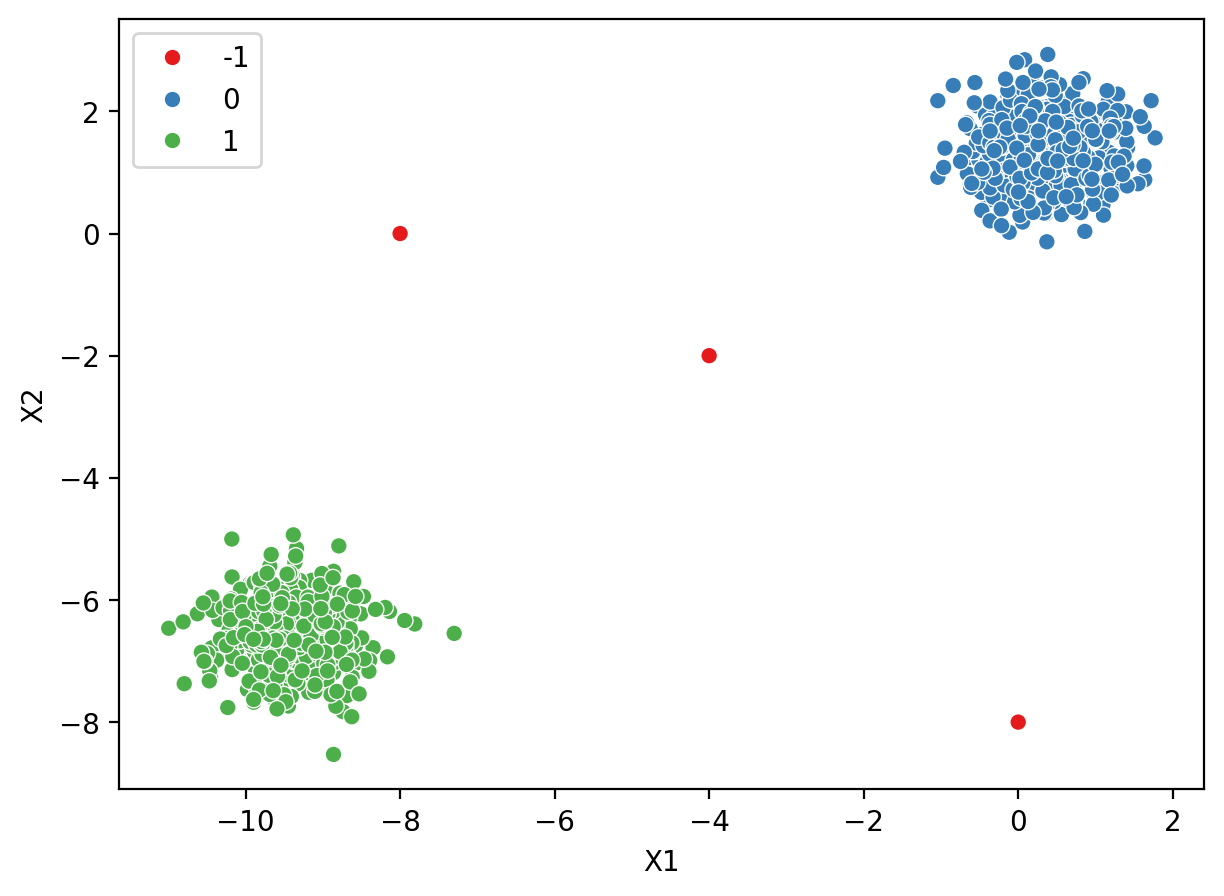

In [38]:
plot(DBSCAN(eps = 0.75, min_samples = 2), two_blobs_outliers)